# Scraping Toyosu fish market HTML documents

Toyosu Weekly fish martket report has prices for Bluefin tuna ("tuna") and Bigeye tuna ("bigeye") from the years 2004 -> 2023 in scrape-able html files. Tables should be consistently formatted up to 2023. After 2023 html file becomes pdf document, and I could manually collect the last two or so years.

Data is weekly.

In [44]:
import requests
from bs4 import BeautifulSoup
import csv
import time
import re
import pandas as pd
import matplotlib.pyplot as plt

/Users/nichosmolnar/.pyenv/versions/3.11.8/lib/python3.11/site-packages/pyparsing/core.py:4332: RuntimeWarning: coroutine 'Translator.translate' was never awaited
  ret = super().copy()


In [ ]:
#Scrape - trying the first page just to check if it works
    #first scrapable page is January 2023 Week 1

url = "https://www.spt.metro.tokyo.lg.jp/shijou/torihiki/03/suisan/2023013.html"
raw_html = requests.get(url).content
soup_doc = BeautifulSoup(raw_html, "html.parser")
print(soup_doc.prettify())

#content is scrapable!


Making a scraping script that will scrape links with the following format: https://www.spt.metro.tokyo.lg.jp/shijou/torihiki/03/suisan/2004011.html
each website is has a table with information I would like to scrape. 

I don't want to get IP blocked so please add a delay for the process with python's time library, with delay=.25

Each weekly report has the same url with a code denoting date at the back. Format is YYYYMMW (Year, Month, Week) Example: 2004011 - 2004, 01 (January), 1 (week 1) 4 weeks is standard, but some have 5 weeks. 
Try 4 weeks, try the fifth and if that gets a "Not Found," don't add data to the table and proceed to the next month. 

Years: 2004 to 2023
Months: 01 to 12
Weeks: 1 to 4 or 5
I want to pull the following rows: 

マグロ (row named マグロ, and the following row)
メバチ (row named メバチ, and only that one) which can be accomplished with regex, probably

These rows are found within /html/body/center/table/tbody/tr/td/table[3] (the third table element within the outermost table element)
data pulled from each row should be put into the final columns, where data from each cell is divided with a pipe |

save each row to a pd dataframe

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re

BASE_URL = "https://www.spt.metro.tokyo.lg.jp/shijou/torihiki/03/suisan/{}.html"

# Delay between requests (seconds)
REQUEST_DELAY = 0.005

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )
}

# ── Column definitions ────────────────────────────────────────────────────────
#
# The detail table (section 2) has these columns left-to-right:
#
#  [ITEM BLOCK]          [VOLUME BLOCK]                    [PRICE BLOCK]
#  品目 | 取扱数量t | 週↑↓ | 前週比 | 前年同期比 | 産地 | 等級 | 高値 | 中値 | 安値 | 前週比 | 前年同期比 | (サイズ)
#   0        1         2       3          4          5      6      7      8      9      10         11          12
#
# First sub-row of an item has all 13 cells.
# Continuation sub-rows (extra origin/grade/price combos) only have 8 cells:
#   産地 | 等級 | 高値 | 中値 | 安値 | 前週比 | 前年同期比 | (サイズ)
#    0      1      2      3      4       5          6           7

FULL_ROW_COLS = [
    "品目",            # 0  item name
    "取扱数量t",        # 1  volume (tonnes)
    "週の状況",         # 2  week trend symbol (↑/↓/→ etc.)
    "前週比",           # 3  vs previous week (%)
    "前年同期比",       # 4  vs same period last year (%)
    "産地",             # 5  origin / fishing ground
    "等級",             # 6  grade / size class
    "高値",             # 7  price high (¥/kg)
    "中値",             # 8  price mid  (¥/kg)
    "安値",             # 9  price low  (¥/kg)
    "前週比_価格",      # 10 price vs prev week (%)
    "前年同期比_価格",  # 11 price vs prev year (%)
    "サイズ",           # 12 size note
]

SUB_ROW_COLS = [        # continuation rows: price block only
    "産地",
    "等級",
    "高値",
    "中値",
    "安値",
    "前週比_価格",
    "前年同期比_価格",
    "サイズ",
]

META_COLS = ["year", "month", "week", "code", "url", "row_type", "sub_row"]
ALL_COLS  = META_COLS + FULL_ROW_COLS


# ── Helpers ───────────────────────────────────────────────────────────────────

def build_url_code(year, month, week):
    return f"{year}{month:02d}{week}"


def fetch_page(url):
    """Fetch page decoded as Shift-JIS. Returns HTML string or None if not found."""
    try:
        resp = requests.get(url, headers=HEADERS, timeout=15)
        if resp.status_code == 404:
            return None
        resp.raise_for_status()
        resp.encoding = "shift_jis"
        return resp.text
    except requests.exceptions.HTTPError as e:
        if e.response.status_code == 404:
            return None
        print(f"  HTTP error for {url}: {e}")
        return None
    except requests.exceptions.RequestException as e:
        print(f"  Request error for {url}: {e}")
        return None


def blank_full_row():
    return {col: "" for col in FULL_ROW_COLS}


def map_full_row(cells):
    """Map a 13-cell row to FULL_ROW_COLS dict."""
    row = blank_full_row()
    for i, col in enumerate(FULL_ROW_COLS):
        if i < len(cells):
            row[col] = cells[i]
    return row


def map_sub_row(cells, parent_item):
    """Map an 8-cell continuation row; inherit item name from parent."""
    row = blank_full_row()
    row["品目"] = parent_item
    for i, col in enumerate(SUB_ROW_COLS):
        if i < len(cells):
            row[col] = cells[i]
    return row


# ── Parser ────────────────────────────────────────────────────────────────────

def parse_table(html):
    """
    Return a list of record dicts for マグロ (+ its following row) and メバチ.
    Each dict has keys from FULL_ROW_COLS plus 'row_type' and 'sub_row'.

    row_type values:
      'マグロ'       – first (main) row of マグロ block
      'マグロ_next'  – the sub-row immediately following マグロ (as requested)
      'メバチ'       – メバチ row
    """
    soup = BeautifulSoup(html, "html.parser")
    all_trs = soup.find_all("tr")
    records = []

    i = 0
    while i < len(all_trs):
        tds   = all_trs[i].find_all(["td", "th"])
        cells = [td.get_text(strip=True) for td in tds]

        is_maguro  = any(re.fullmatch(r"マグロ", c) for c in cells)
        is_mebachi = any(re.fullmatch(r"メバチ", c) for c in cells)

        # ── マグロ block ──────────────────────────────────────────────────────
        if is_maguro:
            # Main row
            records.append({
                "row_type": "マグロ",
                "sub_row":  0,
                **map_full_row(cells),
            })
            i += 1

            # Capture ONLY the one immediately following row as マグロ_next
            if i < len(all_trs):
                ntds = all_trs[i].find_all(["td", "th"])
                nc   = [td.get_text(strip=True) for td in ntds]
                nn   = len(nc)
                if nn > 0:
                    first = nc[0]
                    # Only capture if it's not a new named item
                    if not (nn >= 13 and first and first not in ("", "マグロ")):
                        records.append({
                            "row_type": "マグロ_next",
                            "sub_row":  1,
                            **map_sub_row(nc, "マグロ"),
                        })
                        i += 1

            continue  # don't increment i again

        # ── メバチ (single row only) ──────────────────────────────────────────
        if is_mebachi:
            records.append({
                "row_type": "メバチ",
                "sub_row":  0,
                **map_full_row(cells),
            })

        i += 1

    # Return only the last 3 records (マグロ, マグロ_next, メバチ).
    # Using [-3:] drops any earlier duplicates if the pattern appears more than once.
    return records[-3:] if len(records) >= 3 else records


# ── Main ──────────────────────────────────────────────────────────────────────

def main():
    all_records = []

    years     = range(2004, 2024)   # 2004–2023 inclusive
    months    = range(1, 13)
    max_weeks = 5

    for year in years:
        for month in months:
            for week in range(1, max_weeks + 1):
                code = build_url_code(year, month, week)
                url  = BASE_URL.format(code)

                print(f"Fetching {code} ...", end=" ", flush=True)
                html = fetch_page(url)

                if html is None:
                    msg = "Not found (week 5 — skipping)" if week == 5 else "Not found"
                    print(msg)
                    time.sleep(REQUEST_DELAY)
                    continue

                # Only treat as soft 404 if the page clearly has no real content.
                # Avoid bare "404" substring match — it appears in 2023+ document
                # reference numbers (e.g. 令和5年第2号) embedded in the page header,
                # causing valid pages to be incorrectly skipped.
                page_text = re.sub(r"<[^>]+>", " ", html)
                is_soft_404 = bool(
                    re.search(r"ページが見つかり", page_text)
                    or re.search(r"\bnot\s+found\b", page_text, re.IGNORECASE)
                    or re.search(r"HTTP[/ ]*404", page_text, re.IGNORECASE)
                    # bare 404 only counts on very short pages (real error pages are tiny)
                    or (re.search(r"\b404\b", page_text) and len(page_text.strip()) < 2000)
                )
                if is_soft_404:
                    print("Soft 404 (skipping)")
                    time.sleep(REQUEST_DELAY)
                    continue

                rows = parse_table(html)

                if not rows:
                    print("No matching rows")
                else:
                    print(f"{len(rows)} row(s) captured")
                    for row in rows:
                        record = {
                            "year":     year,
                            "month":    month,
                            "week":     week,
                            "code":     code,
                            "url":      url,
                            "row_type": row.pop("row_type"),
                            "sub_row":  row.pop("sub_row"),
                        }
                        record.update(row)
                        all_records.append(record)

                time.sleep(REQUEST_DELAY)

    df = pd.DataFrame(all_records, columns=ALL_COLS)
    print(f"\nDone! {len(df)} rows collected.")
    print(df.head())
    return df


if __name__ == "__main__":
    df = main()

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re

BASE_URL = "https://www.spt.metro.tokyo.lg.jp/shijou/torihiki/03/suisan/{}.html"

# Delay between requests (seconds)
REQUEST_DELAY = 0.005

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )
}

# ── Column definitions ────────────────────────────────────────────────────────
#
# Full logical row (after rowspan expansion):
#   品名 | 上場数量 | 前週比 | 増減 | 前年同期比 | 増減 | 主産地 | 銘柄 | 高値 | 中値 | 安値 | 前週比_価格 | 前年同期比_価格 | 今週の主力
#    0       1        2       3        4           5      6       7      8      9     10       11              12               13
#
# The first 6 columns (品名 through 増減_前年) span multiple rows via rowspan="N".
# Continuation rows only carry columns 6–13 (主産地 onward).

TABLE_COLS = [
    "品名",           # 0  fish/item name
    "上場数量",        # 1  volume listed
    "前週比",          # 2  vs previous week (volume)
    "増減",            # 3  increase/decrease symbol (volume)
    "前年同期比",      # 4  vs same period last year (volume)
    "増減_前年",       # 5  increase/decrease symbol (prev year)
    "主産地",          # 6  main origin
    "銘柄",            # 7  brand / grade
    "高値",            # 8  price high
    "中値",            # 9  price mid
    "安値",            # 10 price low
    "前週比_価格",     # 11 price vs prev week
    "前年同期比_価格", # 12 price vs prev year
    "今週の主力",      # 13 this week's main note
]

META_COLS = ["year", "month", "week", "code", "url"]
ALL_COLS  = META_COLS + TABLE_COLS


# ── Helpers ───────────────────────────────────────────────────────────────────

def build_url_code(year, month, week):
    return f"{year}{month:02d}{week}"


def fetch_page(url):
    """Fetch page decoded as Shift-JIS. Returns HTML string or None if not found."""
    try:
        resp = requests.get(url, headers=HEADERS, timeout=15)
        if resp.status_code == 404:
            return None
        resp.raise_for_status()
        resp.encoding = "shift_jis"
        return resp.text
    except requests.exceptions.HTTPError as e:
        if e.response.status_code == 404:
            return None
        print(f"  HTTP error: {e}")
        return None
    except requests.exceptions.RequestException as e:
        print(f"  Request error: {e}")
        return None


def find_target_table(soup):
    """
    Locate the fish-price detail table.

    The page uses zero <div> tags — it is pure nested <table> elements.
    The target table is uniquely identified by having a header row whose
    *direct* child cells include all three of: 高値, 中値, 安値.

    We check direct-child <tr> rows only (not rows from nested sub-tables)
    to avoid matching a parent wrapper table. Then we return the innermost
    candidate so we get the actual data table, not a container around it.
    """
    header_markers = {"高値", "中値", "安値"}

    candidates = []
    for table in soup.find_all("table"):
        # Collect only direct-child <tr> rows (via tbody/thead too, but not nested tables)
        direct_trs = []
        for child in table.children:
            if getattr(child, "name", None) == "tr":
                direct_trs.append(child)
            elif getattr(child, "name", None) in ("tbody", "thead", "tfoot"):
                for sub in child.children:
                    if getattr(sub, "name", None) == "tr":
                        direct_trs.append(sub)

        for tr in direct_trs[:3]:
            # Use recursive=False so we only see cells directly in this tr,
            # not cells from any nested table inside a td
            cells = {td.get_text(strip=True) for td in tr.find_all(["td", "th"], recursive=False)}
            if header_markers.issubset(cells):
                candidates.append(table)
                break

    if not candidates:
        return None

    # Return the innermost candidate: the one that is not an ancestor of another candidate
    for table in candidates:
        if not any(other is not table and other in table.descendants for other in candidates):
            return table

    return candidates[0]


def parse_table(html):
    """
    Parse the target fish-price table from the page HTML.

    Rowspan handling:
      - The first 6 columns (品名 … 増減_前年) may have rowspan > 1.
      - We carry those values forward into continuation rows until a new
        rowspan > 1 is encountered in column 0.
      - The first 2 <tr> elements are headers — skipped.

    Returns a list of dicts with keys matching TABLE_COLS.
    """
    soup = BeautifulSoup(html, "html.parser")
    table = find_target_table(soup)
    if table is None:
        return []

    all_trs = table.find_all("tr")

    # Skip the first 2 rows (column headers, same on every page)
    data_rows = all_trs[2:]
    if not data_rows:
        return []

    records = []

    # State: the last seen "header block" (cols 0–5) carried via rowspan
    carried = [""] * 6   # values for 品名 … 増減_前年
    remaining_span = 0   # how many more rows the carried block should apply to

    for tr in data_rows:
        tds = tr.find_all(["td", "th"])
        if not tds:
            continue

        # ── Detect rowspan on the first cell ─────────────────────────────────
        first_td   = tds[0]
        rowspan    = int(first_td.get("rowspan", 1))
        first_text = first_td.get_text(strip=True)

        if rowspan > 1:
            # This row starts a new item block — read cols 0–5 from the TR
            carried = [td.get_text(strip=True) for td in tds[:6]]
            remaining_span = rowspan  # counts down as continuation rows arrive
            price_tds = tds[6:]      # cols 6–13 are in this same TR
        else:
            # Continuation row — only cols 6–13 are present in the HTML
            # (cols 0–5 are omitted because they were rowspan'd above)
            if remaining_span > 1:
                remaining_span -= 1
                price_tds = tds  # entire TR is the price block
            else:
                # rowspan=1: self-contained single row with all 14 cols
                carried = [td.get_text(strip=True) for td in tds[:6]]
                price_tds = tds[6:]

        # ── Build full logical row ────────────────────────────────────────────
        price_vals = [td.get_text(strip=True) for td in price_tds]

        # Pad to 8 cols (主産地 … 今週の主力) in case trailing cells are absent
        price_vals += [""] * (8 - len(price_vals))
        price_vals = price_vals[:8]

        full_vals = list(carried) + price_vals  # 6 + 8 = 14 values
        record = dict(zip(TABLE_COLS, full_vals))
        records.append(record)

    return records


# ── Main ──────────────────────────────────────────────────────────────────────

def main():
    all_records = []

    years     = range(2004, 2024)   # 2004–2023 inclusive
    months    = range(1, 13)
    max_weeks = 5

    for year in years:
        for month in months:
            for week in range(1, max_weeks + 1):
                code = build_url_code(year, month, week)
                url  = BASE_URL.format(code)

                print(f"Fetching {code} ...", end=" ", flush=True)
                html = fetch_page(url)

                if html is None:
                    msg = "Not found (week 5 — skipping)" if week == 5 else "Not found"
                    print(msg)
                    time.sleep(REQUEST_DELAY)
                    continue

                # Soft-404 guard: match only unambiguous not-found signals.
                # Avoid bare "404" substring — it appears in 2023+ document
                # reference numbers in the page header.
                page_text = re.sub(r"<[^>]+>", " ", html)
                is_soft_404 = bool(
                    re.search(r"ページが見つかり", page_text)
                    or re.search(r"\bnot\s+found\b", page_text, re.IGNORECASE)
                    or re.search(r"HTTP[/ ]*404", page_text, re.IGNORECASE)
                    or (re.search(r"\b404\b", page_text) and len(page_text.strip()) < 2000)
                )
                if is_soft_404:
                    print("Soft 404 (skipping)")
                    time.sleep(REQUEST_DELAY)
                    continue

                rows = parse_table(html)

                if not rows:
                    print("No matching rows")
                else:
                    print(f"{len(rows)} row(s) captured")
                    meta = {
                        "year":  year,
                        "month": month,
                        "week":  week,
                        "code":  code,
                        "url":   url,
                    }
                    for row in rows:
                        all_records.append({**meta, **row})

                time.sleep(REQUEST_DELAY)

    df = pd.DataFrame(all_records, columns=ALL_COLS)
    print(f"\nDone! {len(df)} rows collected.")
    print(df.head())
    return df


if __name__ == "__main__":
    df = main()

Fetching 2004011 ... 23 row(s) captured
Fetching 2004012 ... 23 row(s) captured
Fetching 2004013 ... 23 row(s) captured
Fetching 2004014 ... 23 row(s) captured
Fetching 2004015 ... Not found (week 5 — skipping)
Fetching 2004021 ... 23 row(s) captured
Fetching 2004022 ... 23 row(s) captured
Fetching 2004023 ... 23 row(s) captured
Fetching 2004024 ... 23 row(s) captured
Fetching 2004025 ... Not found (week 5 — skipping)
Fetching 2004031 ... 23 row(s) captured
Fetching 2004032 ... 23 row(s) captured
Fetching 2004033 ... 23 row(s) captured
Fetching 2004034 ... 23 row(s) captured
Fetching 2004035 ... Not found (week 5 — skipping)
Fetching 2004041 ... 21 row(s) captured
Fetching 2004042 ... 21 row(s) captured
Fetching 2004043 ... 21 row(s) captured
Fetching 2004044 ... 21 row(s) captured
Fetching 2004045 ... 21 row(s) captured
Fetching 2004051 ... 21 row(s) captured
Fetching 2004052 ... 21 row(s) captured
Fetching 2004053 ... 21 row(s) captured
Fetching 2004054 ... 21 row(s) captured
Fetchin

In [2]:
df.head(23)

,year,month,week,code,url,品名,上場数量,前週比,増減,前年同期比,増減_前年,主産地,銘柄,高値,中値,安値,前週比_価格,前年同期比_価格,今週の主力
0,2004,1,1,2004011,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,マグロ,49.2,74,↓,112,↑,各地,生,"27,300","6,009","2,100",108,94,
1,2004,1,1,2004011,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,マグロ,49.2,74,↓,112,↑,海外,生,"9,450","2,987","1,890",112,76,
2,2004,1,1,2004011,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,メバチ,97.9,60,↓,82,↓,各地*,冷凍,"4,200","1,095",578,100,111,
3,2004,1,1,2004011,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,アジ,47.3,84,↓,119,↑,富山ほか,中,"1,470",788,210,134,79,
4,2004,1,1,2004011,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,アジ,47.3,84,↓,119,↑,鳥取ほか,中小,840,420,315,123,50,
5,2004,1,1,2004011,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,サバ,20.8,103,,121,↑,静岡ほか,−,"4,200","2,021",420,166,164,500-600g/尾
6,2004,1,1,2004011,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,イワシ,14.1,261,↑,121,↑,千葉ほか,−,"1,470",788,315,75,79,90g以下/尾
7,2004,1,1,2004011,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,スルメイカ,36.9,132,↑,73,↓,福岡ほか,−,945,635,168,98,113,5kg/20入
8,2004,1,1,2004011,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,冷ｽﾙﾒｲｶ,17.1,51,↓,62,↓,各地,−,315,276,263,100,93,
9,2004,1,1,2004011,https://www.spt.metro.tokyo.lg.jp/shijou/torih...,サンマ,13.0,102,,107,,各地,解凍,788,289,210,110,79,


In [4]:
#translate japanese column names to english for easier handling
df = df.rename(columns={
    "品名": "item",
    "上場数量": "volume",
    "前週比": "vs_prev_week",
    "増減": "week_trend",
    "前年同期比": "vs_prev_year",
    "増減_前年": "year_trend",
    "主産地": "origin",
    "銘柄": "grade",
    "高値": "price_high",
    "中値": "price_mid",
    "安値": "price_low",
    "前週比_価格": "price_vs_prev_week",
    "前年同期比_価格": "price_vs_prev_year",
    "今週の主力": "this_week_main",
})

#drop url, vs_prev_week, week_trend, vs_prev_year, year_trend, price_vs_prev_week, price_vs_prev_year, this_week_main
df = df.drop(columns=[
    "url",
    "vs_prev_week",
    "week_trend",
    "vs_prev_year",
    "year_trend",
    "price_vs_prev_week",
    "price_vs_prev_year",
    "this_week_main",
])




KeyError: "['url', 'vs_prev_week', 'week_trend', 'vs_prev_year', 'year_trend', 'price_vs_prev_week', 'price_vs_prev_year', 'this_week_main'] not found in axis"

In [12]:
#convert price columns to float type, removing commas and handling empty strings. currently are objects. if empty string, replace with 0 before converting to float.
# if "-" (dash) is present, treat as 0 as well since it indicates no price available for that cell.
for col in ["price_high", "price_mid", "price_low"]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace(["", "-", "−"], "0")
    )
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

In [14]:
#convert float to int for price cols if you did the steps out of order
df["price_high"] = df["price_high"].astype("Int64")
df["price_mid"] = df["price_mid"].astype("Int64")
df["price_low"] = df["price_low"].astype("Int64")

In [15]:
df.dtypes

year           int64
month          int64
week           int64
code          object
item          object
volume        object
origin        object
grade         object
price_high     Int64
price_mid      Int64
price_low      Int64
dtype: object

In [16]:
df.shape
#export to csv and re-import
df.to_csv("../datasets/toyosu_prices_all.csv", index=False)
df = pd.read_csv("../datasets/toyosu_prices_all.csv")
df.head()

,year,month,week,code,item,volume,origin,grade,price_high,price_mid,price_low
0,2004,1,1,2004011,マグロ,49.2,各地,生,27300,6009,2100
1,2004,1,1,2004011,マグロ,49.2,海外,生,9450,2987,1890
2,2004,1,1,2004011,メバチ,97.9,各地*,冷凍,4200,1095,578
3,2004,1,1,2004011,アジ,47.3,富山ほか,中,1470,788,210
4,2004,1,1,2004011,アジ,47.3,鳥取ほか,中小,840,420,315


#### setup for price, yearly average

In [17]:
df.dtypes

year            int64
month           int64
week            int64
code            int64
item           object
volume        float64
origin         object
grade          object
price_high      int64
price_mid       int64
price_low       int64
dtype: object

In [25]:
#translate items to english using googletrans library. translate item column to item_en column
from googletrans import Translator
import asyncio

translator = Translator()

async def translate_item(text):
    if pd.isna(text) or str(text).strip() == "":
        return ""
    try:
        result = await translator.translate(str(text), src="ja", dest="en")
        return result.text
    except Exception:
        return str(text)

unique_items = df["item"].dropna().unique()
translations = await asyncio.gather(*(translate_item(item) for item in unique_items))
item_map = dict(zip(unique_items, translations))

df["item_en"] = df["item"].map(item_map).fillna("")

In [40]:
#some fixes:
    #only first word of item name should be capitalized
df["item_en"] = df["item_en"].str.capitalize()
#Mukikaki to Mukikaki oysters
df["item_en"] = df["item_en"].replace("Mukikaki", "Mukikaki Oysters")
#Cod cod/salt cod to Salt cod
df["item_en"] = df["item_en"].replace("Cod cod/salt cod", "Salt Cod")
#Buri warasa Japanese Yellowtail
df["item_en"] = df["item_en"].replace("Buri warasa", "Japanese yellowtail")
#Meji to Young bluefin tuna
df["item_en"] = df["item_en"].replace("Meji", "Young Bluefin Tuna")
#Tuna to Bluefin Tuna
df["item_en"] = df["item_en"].replace("Tuna", "Bluefin Tuna")

#drop "*for the median price of tuna (raw) in each region, the first market day (5th) is excluded from the calculation."
df = df[df["item_en"] != "*for the median price of tuna (raw) in each region, the first market day (5th) is excluded from the calculation."]


In [41]:
df["item_en"].value_counts()

item_en
Flatfish                         4085
Bluefin tuna                     2044
Horse mackerel                   2044
Salted salmon                    2033
Cod                              1336
Pacific saury                    1195
Mukikaki oysters                 1126
Common squid                     1022
Chilled japanese surume squid    1022
Sardine                          1022
Bigeye                           1022
Mackerel                         1022
Kinmedai                         1022
Yellowtail                       1022
Bonito                           1012
Salt cod                          707
Japanese yellowtail                32
Young bluefin tuna                 14
Name: count, dtype: int64

In [42]:
df_average_all = df.copy()
#average price each year for each item_en
df_average_all = df_average_all.groupby(["year", "item_en"]).agg({
    "price_high": "mean",
    "price_mid": "mean",
    "price_low": "mean",
}).reset_index()
df_average_all.head()



,year,item_en,price_high,price_mid,price_low
0,2004,Bigeye,4681.764706,918.666667,588.490196
1,2004,Bluefin tuna,10256.029412,3641.176471,1653.235294
2,2004,Bonito,2095.882353,786.117647,277.960784
3,2004,Chilled japanese surume squid,361.058824,318.254902,284.333333
4,2004,Common squid,875.372549,564.803922,251.019608


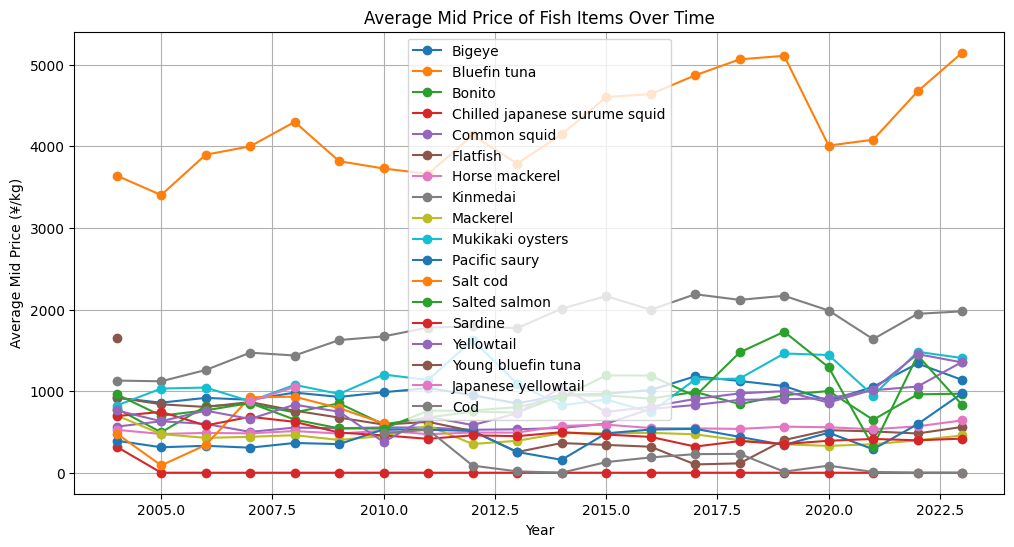

In [45]:
#graph average price of each item_en over time
plt.figure(figsize=(12, 6))
for item in df_average_all["item_en"].unique():
    item_data = df_average_all[df_average_all["item_en"] == item]
    plt.plot(item_data["year"], item_data["price_mid"], marker="o", label=item)
plt.title("Average Mid Price of Fish Items Over Time")
plt.xlabel("Year")
plt.ylabel("Average Mid Price (¥/kg)")
plt.legend()
plt.grid()
plt.show()

In [20]:
#combine non-マグロ and non-メバチ items into "seafood_other"
def categorize_item(item):
    if item == "マグロ":
        return "bluefin_tuna"
    elif item == "メバチ":
        return "bigeye_tuna"
    else:
        return "seafood_other"

df_prep_for_average_price = df.copy()
df_prep_for_average_price["item_category"] = df_prep_for_average_price["item"].apply(categorize_item)
df_prep_for_average_price.head(10)

#for each year, get the average price_high, price_mid, price_low for 
    #マグロ
    #メバチ
    #and then average of everything else combined (excluding マグロ and メバチ) as "seafood_other"

df_avg_prices = df_prep_for_average_price.groupby(["year", "item_category"]).agg({
    "price_high": "mean",
    "price_mid": "mean",
    "price_low": "mean",
}).reset_index()
#convert prices

df_avg_prices.head(20)

,year,item_category,price_high,price_mid,price_low
0,2004,bigeye_tuna,4681.764706,918.666667,588.490196
1,2004,bluefin_tuna,10256.029412,3641.176471,1653.235294
2,2004,seafood_other,1354.784836,732.421107,460.564549
3,2005,bigeye_tuna,4634.411765,858.764706,508.745098
4,2005,bluefin_tuna,9110.294118,3403.049020,1494.705882
5,2005,seafood_other,1276.347692,597.821538,439.876923
6,2006,bigeye_tuna,4572.647059,917.196078,619.803922
7,2006,bluefin_tuna,10102.647059,3897.509804,1694.941176
8,2006,seafood_other,1315.079511,642.618756,441.725790
9,2007,bigeye_tuna,4646.250000,894.019231,619.000000


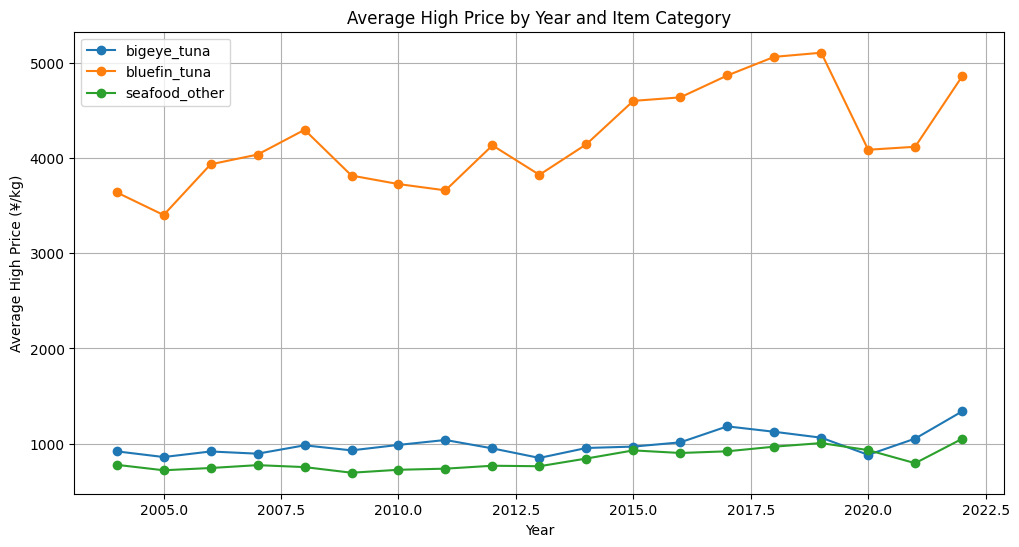

In [56]:
#graph the average price_high for マグロ, メバチ, and seafood_other over time (by year)
plt.figure(figsize=(12, 6))
for category in df_avg_prices["item_category"].unique():
    subset = df_avg_prices[df_avg_prices["item_category"] == category]
    plt.plot(subset["year"], subset["price_mid"], marker="o", label=category)
plt.title("Average High Price by Year and Item Category")
plt.xlabel("Year")
plt.ylabel("Average High Price (¥/kg)")
plt.legend()
plt.grid()
plt.show()

### export bluefin tuna average prices by year

In [46]:
df_average_all.to_csv("../datasets/export/toyosu_avg_all.csv", index=False)
df_avg_prices.to_csv("../datasets/export/toyosu_avg_prices_year.csv", index=False)

#### old stuff below

In [ ]:
#get only マグロ rows from each week along with volume_tonnes, price_high, price_mid, price_low, and origin
df_tonne_price_only = df[df["row_type"] == "tuna"][["year", "month", "week", "origin", "volume_tonnes", "price_high", "price_mid", "price_low"]]

In [ ]:
df_tonne_price_only.head()
#volume_tonnes  should be numeric (float), but they are currently strings
df_tonne_price_only["volume_tonnes"] = pd.to_numeric(df_tonne_price_only["volume_tonnes"], errors="coerce")

#prices should be integers, but are currently strings with commas - remove commas and convert to numeric
for col in ["price_high", "price_mid", "price_low"]:
    df_tonne_price_only[col] = df_tonne_price_only[col].str.replace(",", "")
    df_tonne_price_only[col] = pd.to_numeric(df_tonne_price_only[col], errors="coerce")

df_tonne_price_only.dtypes

#reset index after filtering
df_tonne_price_only = df_tonne_price_only.reset_index(drop=True)

In [ ]:
#approximate conversion:
    #1 tonne = 1000kg
    #1 fish ~ 250kg 
    #round to nearest whole fish
df_tonne_price_only["approx_fish_count"] = ((df_tonne_price_only["volume_tonnes"] * 1000) / 250).round().astype("Int64")
#add week_number (1 through 52, resets each year)
df_tonne_price_only["week_number"] = df_tonne_price_only.index + 1



#add week_id in the format YYYY-MM-WW (e.g. 2023-01-1 for January 2023 Week 1)
df_tonne_price_only["week_id"] = df_tonne_price_only.apply(lambda row: f"{row['year']}-{row['month']:02d}-{row['week']}", axis=1)


df_tonne_price_only.head()

In [ ]:


#barplot. number of fish on y-axis, week_number on x-axis
plt.figure(figsize=(12, 6))
plt.bar(df_tonne_price_only["week_number"], df_tonne_price_only["approx_fish_count"], color="blue", alpha=0.7)
plt.xlabel("Week Number")
plt.ylabel("Approximate Fish Count")
plt.title("Approximate Number of Tuna Fish Sold at Toyosu Market in 2023")
plt.xticks(range(1, 53))  # Show all week numbers on x-axis
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
#export 2023 tuna price and volume data to CSV
df_tonne_price_only.to_csv("../datasets/toyosu_tuna_04-23.csv", index=False)


In [ ]:
#re-import the CSV
df_reimport = pd.read_csv("../datasets/toyosu_tuna_04-23.csv")

In [ ]:
df_reimport.head()

In [ ]:
#graph of price_mid over every week since 2004 from df_reimport, week_number on x-axis, no lines
plt.figure(figsize=(12, 6))
plt.scatter(df_reimport["week_number"], df_reimport["price_mid"], color="red", alpha=0.7)
plt.xlabel("Week Number")
plt.ylabel("Mid Price (¥/kg)")
plt.title("Mid Price of Tuna at Toyosu Market (2004-2023)")
plt.show()